# Full Implementation of Cell Cycle Trajectory Inference from scRNA-seq Data

Importing Packages

In [9]:
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import scipy.sparse as sp
from scipy.sparse.linalg import eigsh
import warnings
warnings.filterwarnings("ignore", category = UserWarning, module = "openpyxl")
from data.preprocess.preprocess import loadData, readMarkerSets, revelio_like_preprocess
from data_structure.weighted_knn import weighted_knn
from trajectory_inference.Laplacian_Eigenmaps import fullLaplacian
from trajectory_inference.diffusion_maps import fullDiffusion
# from trajectory_inference.trajectory_validation import
from scipy.stats import rankdata
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

Load in raw scRNA-seq data and cell cycle phase marker gene set

In [2]:
# marker gene set -- CSV from Schwabe et al. paper

countdf = loadData("../data/GSE142277/GSM4224315_out_gene_exon_tagged.dge_exonssf002_WT.txt")
marker_dict = readMarkerSets("../data/GSE142277/revelio_gene_sets.csv", format = "csv")

### Preprocessing Data

In [3]:
adata = revelio_like_preprocess(countdf, marker_dict)

G1.S 132 ['ABCA7', 'ACD', 'ACYP1', 'ADAMTS1', 'ADCK2', 'ADCY6', 'ANKRD10', 'AP4B1', 'APEX2', 'ARGLU1']
S 147 ['ABCC2', 'ABCC5', 'ABHD10', 'ACPP', 'ADAM22', 'ANKRD18A', 'ANKRD36', 'ARHGAP42', 'ASF1B', 'ATAD2']
G2 160 ['ALKBH1', 'ANLN', 'AP3D1', 'ARHGAP11B', 'ARHGAP19', 'ARL4A', 'ARMC1', 'ASXL1', 'ATL2', 'AURKB']
G2.M 186 ['AHI1', 'AKIRIN2', 'ANKRD40', 'ANLN', 'ANP32B', 'ANP32E', 'ARHGAP19', 'ARHGDIB', 'ARL6IP1', 'ASXL1']
M.G1 127 ['AFAP1', 'AGFG1', 'AGPAT3', 'AKAP13', 'AMD1', 'ANP32E', 'ANTXR1', 'BAG3', 'BTBD3', 'C3orf62']


### KNN Classification and Laplacian Eigenmaps

In [25]:
lapEmbed, lapEigval, lapPs = fullLaplacian(adata, k = 12)

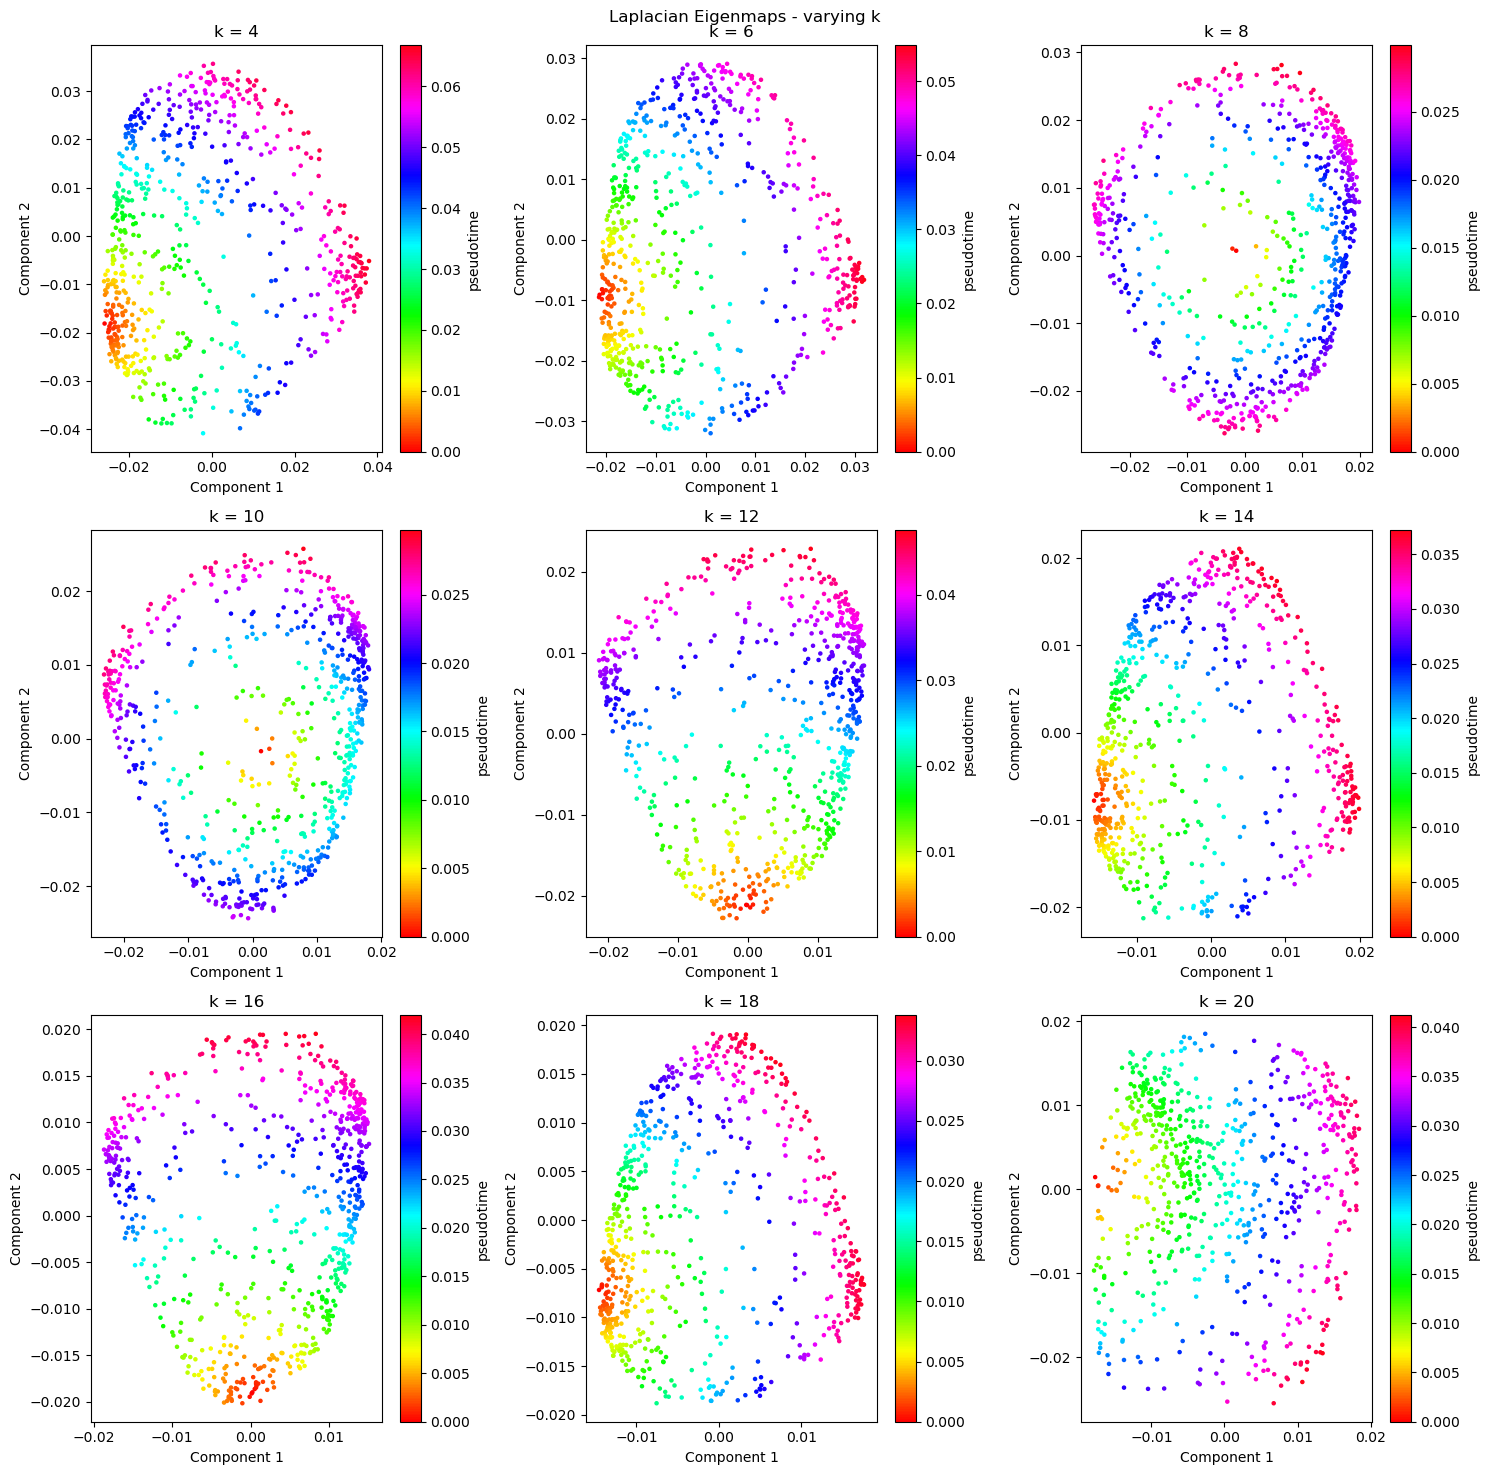

In [26]:
kVals = list(range(4, 22, 2))
fig, axes = plt.subplots(3, 3, figsize = (15, 15))
axes = axes.flatten()

for i, k in enumerate(kVals):
    lapEmbed, lapEigval, lapPs = fullLaplacian(adata, k = k)
    sc = axes[i].scatter(lapEmbed[:, 0], lapEmbed[:, 1], c = lapPs, cmap = "hsv", s = 5)
    axes[i].set_title(f"k = {k}")
    axes[i].set_xlabel("Component 1")
    axes[i].set_ylabel("Component 2")
    plt.colorbar(sc, ax = axes[i], label = "pseudotime")

plt.suptitle("Laplacian Eigenmaps - varying k")
plt.tight_layout()
plt.show()

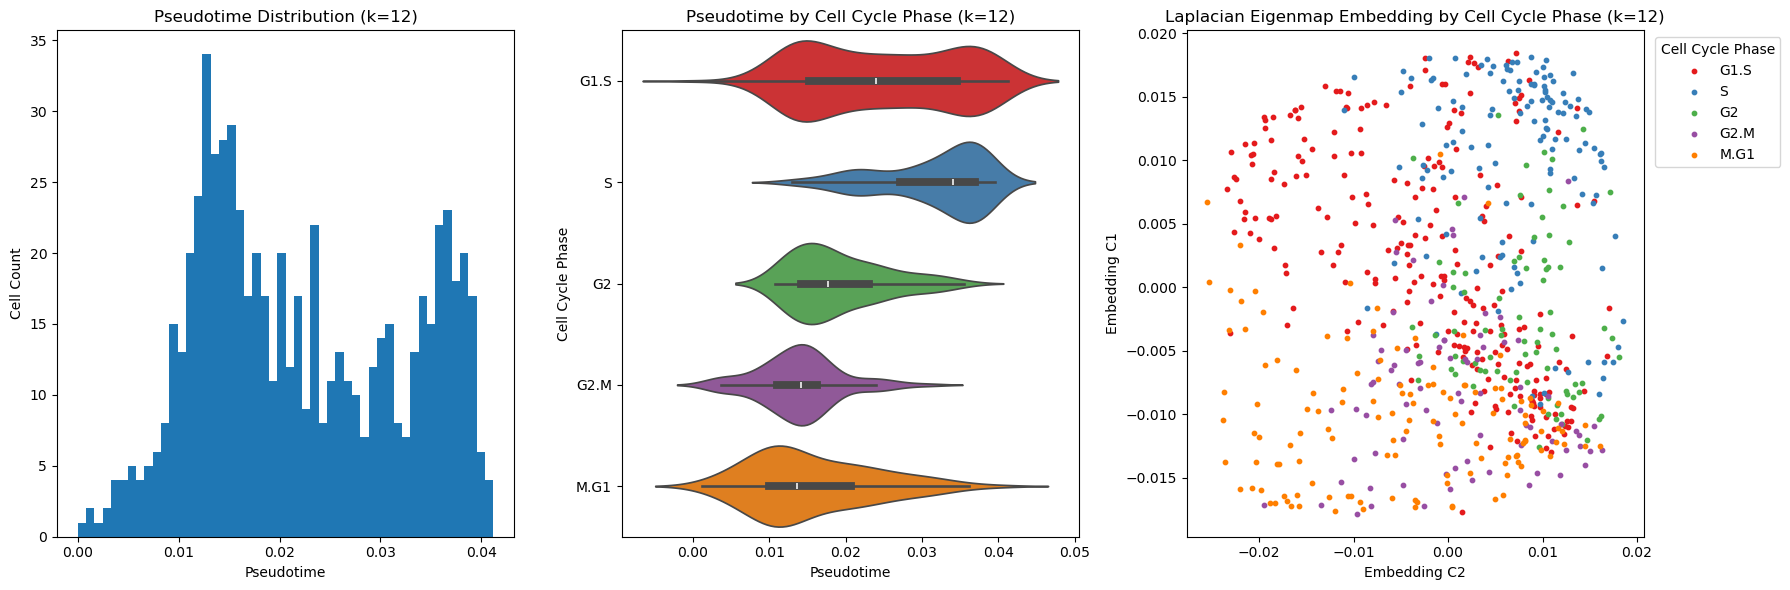

In [6]:
phases = ["G1.S", "S", "G2", "G2.M", "M.G1"]
colors = sns.color_palette("Set1", len(phases))
plotDF = pd.DataFrame({"pseudotime": lapPs, "phase": adata.obs["cc_phase"].values})

fig, axes = plt.subplots(1, 3, figsize = (18, 6))

# Left -- cell count vs. pseudotime histogram
axes[0].hist(lapPs, bins = 50)
axes[0].set_xlabel("Pseudotime")
axes[0].set_ylabel("Cell Count")
axes[0].set_title("Pseudotime Distribution (k=12)")

# Middle -- violin plot of pseudotime by phase
sns.violinplot(data = plotDF, x = "pseudotime", y = "phase", hue = "phase", order = phases, palette = "Set1", legend = False, ax = axes[1])
axes[1].set_xlabel("Pseudotime")
axes[1].set_ylabel("Cell Cycle Phase")
axes[1].set_title("Pseudotime by Cell Cycle Phase (k=12)")

# Right -- scatter of embedding colored by phase
for phase, color in zip(phases, colors):
    mask = adata.obs["cc_phase"] == phase
    axes[2].scatter(lapEmbed[mask, 1], lapEmbed[mask, 0], label = phase, color = color, s = 10)
axes[2].set_title("Laplacian Eigenmap Embedding by Cell Cycle Phase (k=12)")
axes[2].set_xlabel("Embedding C2")
axes[2].set_ylabel("Embedding C1")
axes[2].legend(title = "Cell Cycle Phase", bbox_to_anchor = (1.01, 1), loc = "upper left")

plt.tight_layout()
plt.show()

### KNN Classification and Diffusion Maps

In [56]:
difEmbed, difLambdas, difPsis, dpt = fullDiffusion(adata, k = 5)

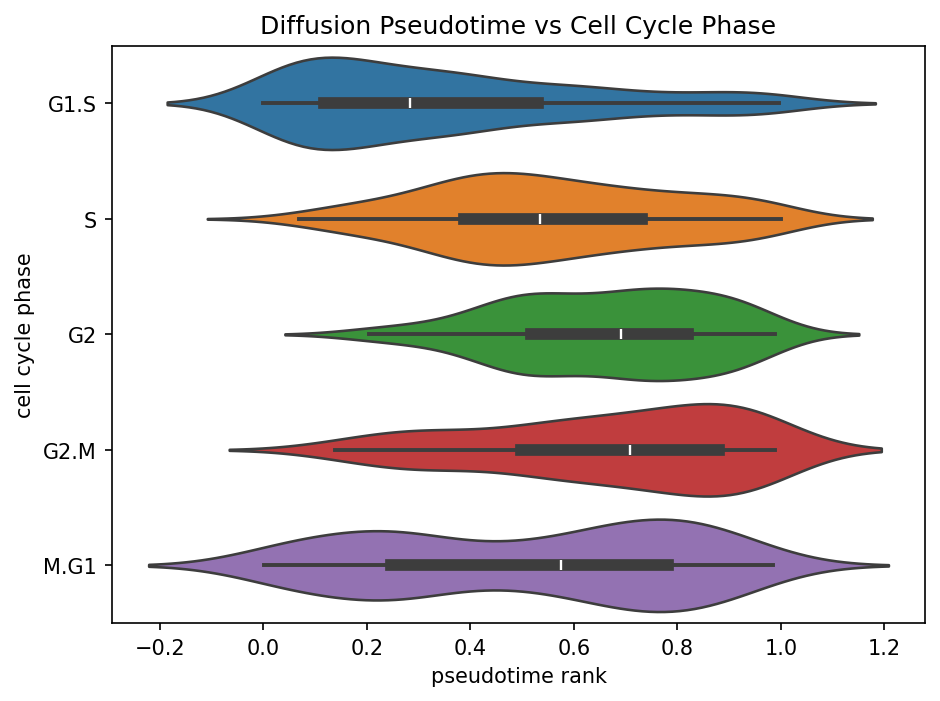

In [57]:
## violin plot of pseudotime vs cell cycle phase

# adding pseudotime to adata
adata.obs['dpt'] = dpt
# ranking pseudotime
dpt_rank = (rankdata(dpt) - 1) / (len(dpt) - 1)
# adding in ranks of pseudotimes
adata.obs['dpt_rank'] = dpt_rank
# reordering cell cycle column into biological order
adata.obs['cc_phase'] = pd.Categorical(adata.obs['cc_phase'],categories=['G1.S','S','G2','G2.M','M.G1'],ordered=True)

fig,ax = plt.subplots(figsize=(7,5),dpi=150)
sns.violinplot(data=adata.obs, x='dpt_rank', y='cc_phase', hue='cc_phase', ax=ax, palette='tab10')
ax.set_ylabel('cell cycle phase')
ax.set_xlabel('pseudotime rank')
ax.set_title('Diffusion Pseudotime vs Cell Cycle Phase')
plt.show()

In [58]:
adata.obs[[f"DC{i}" for i in range(len(difEmbed[0]))]] = difEmbed

adata.obs[[f"PC{i}" for i in range(len(adata.obsm["X_pca"][0]))]] = adata.obsm["X_pca"]
adata.obs[[f"EV{i}" for i in range(len(difPsis[0]))]] = difPsis

fig = px.scatter_3d(
    adata.obs,
    x="PC1",
    y="PC2",
    z="PC3",
    color="cc_phase",
    hover_data=["cc_phase","dpt_rank","dpt"],
    title="3D diffusion map colored by pseudotime",
    width=1000,
    height=1000,
)
fig.update_traces(marker=dict(size=5))

fig.show()

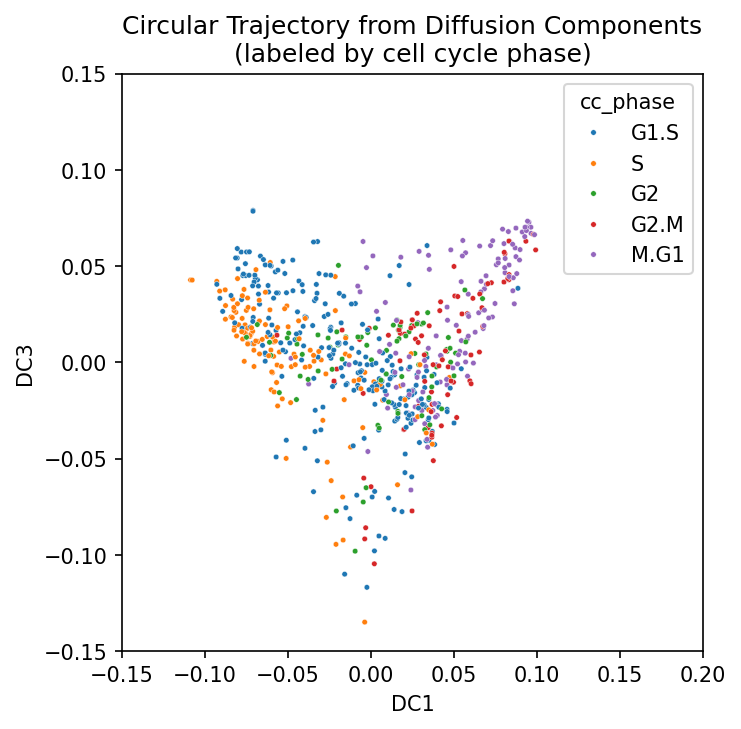

In [53]:
fig,ax = plt.subplots(figsize=(5,5),dpi=150)
sns.scatterplot(data=adata.obs,x='DC1',y='DC3',hue='cc_phase',palette='tab10',ax=ax,s=7)
ax.set_title('Circular Trajectory from Diffusion Components\n(labeled by cell cycle phase)')
ax.set_ylim([-0.15,0.15])
ax.set_xlim([-0.15,0.2])
plt.show()